In [1]:
import os
import numpy as np
import nibabel as nib
import pandas as pd
import cv2
from glob import glob

import torch
import torch.nn as nn
import torchvision.models as models

from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    recall_score,
    f1_score,
    accuracy_score
)

import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


## BUILD CASE-LEVEL LABEL TABLE (FROM MASKS)

In [3]:
def get_case_label(mask_path):
    mask = nib.load(mask_path).get_fdata().astype(np.int16)
    unique_labels = np.unique(mask)

    if 3 in unique_labels:
        return 3
    elif 2 in unique_labels:
        return 2
    else:
        return None


In [4]:
MASK_DIR = r"D:\Similiar_Colorectum\14004841\lms\lms"

case_ids, labels = [], []

for file in os.listdir(MASK_DIR):
    if file.endswith(".nii.gz"):
        case_id = file.split("_")[1]  # crc_CRC071_*.nii.gz → CRC071
        label = get_case_label(os.path.join(MASK_DIR, file))
        if label is not None:
            case_ids.append(case_id)
            labels.append(label)

df = pd.DataFrame({
    "case_id": case_ids,
    "label": labels
})

print(df['label'].value_counts())


label
2    86
3    30
Name: count, dtype: int64


In [5]:
df_path = r"D:\Similiar_Colorectum\14004841\case_labels.csv"
df.to_csv(df_path, index=False)


## LOAD CT + MASK AND SELECT TUMOR SLICES ONLY

In [6]:
def get_tumor_slices(ct_path, mask_path):
    ct = nib.load(ct_path).get_fdata()
    mask = nib.load(mask_path).get_fdata()

    tumor_slices = []

    for z in range(ct.shape[2]):
        mask_slice = mask[:, :, z]
        if np.any((mask_slice == 2) | (mask_slice == 3)):
            tumor_slices.append(ct[:, :, z])

    return tumor_slices


## CT PREPROCESSING (CORRECT FOR MEDICAL DATA)

In [7]:
def preprocess_slice(slice2d, size=224):
    slice2d = np.nan_to_num(slice2d)

    # CT window
    wl, ww = 40, 400
    low, high = wl - ww//2, wl + ww//2
    slice2d = np.clip(slice2d, low, high)

    # Normalize
    slice2d = (slice2d - slice2d.min()) / (slice2d.max() - slice2d.min() + 1e-6)

    slice2d = cv2.resize(slice2d, (size, size))
    slice2d = np.stack([slice2d]*3, axis=0)

    return torch.tensor(slice2d, dtype=torch.float32)


## CNN FEATURE EXTRACTOR

In [8]:
resnet = models.resnet18(pretrained=True)
resnet.fc = nn.Identity()   # remove classifier
resnet = resnet.to(device)
resnet.eval()


c:\Users\100ra\anaconda3\envs\ram_env\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\100ra\anaconda3\envs\ram_env\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## EXTRACT FEATURES FOR ONE PATIENT (MIL INSTANCES)

In [9]:
def extract_case_features(ct_path, mask_path):
    slices = get_tumor_slices(ct_path, mask_path)
    features = []

    with torch.no_grad():
        for s in slices:
            img = preprocess_slice(s).unsqueeze(0).to(device)
            feat = resnet(img)
            features.append(feat.cpu().numpy())

    return np.vstack(features)  # (num_slices, 512)


## MIL POOLING (CASE-LEVEL REPRESENTATION)

In [10]:
def mil_mean_pool(features):
    return features.mean(axis=0)


## BUILD FINAL DATASET (ONE ROW = ONE PATIENT)

In [11]:
IMG_DIR  = r"D:\Similiar_Colorectum\14004841\images\images"
MASK_DIR = r"D:\Similiar_Colorectum\14004841\lms\lms"

X, y = [], []

for case_id, label in zip(df.case_id, df.label):

    ct_candidates = glob(f"{IMG_DIR}/crc_{case_id}_*.nii.gz")
    mask_candidates = glob(f"{MASK_DIR}/crc_{case_id}_*.nii.gz")

    if len(ct_candidates) == 0 or len(mask_candidates) == 0:
        continue

    ct_path = ct_candidates[0]
    mask_path = mask_candidates[0]

    feats = extract_case_features(ct_path, mask_path)
    case_feat = mil_mean_pool(feats)

    X.append(case_feat)
    y.append(label)

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)  # (≈116, 512)
print("y shape:", y.shape)


X shape: (116, 512)
y shape: (116,)


## CASE-LEVEL CLASSIFIER

In [12]:
clf = LogisticRegression(
    class_weight="balanced",
    max_iter=1000
)


## STRATIFIED CROSS-VALIDATION + METRICS

In [13]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

all_true, all_pred = [], []

for train_idx, val_idx in skf.split(X, y):
    clf.fit(X[train_idx], y[train_idx])
    preds = clf.predict(X[val_idx])

    all_true.extend(y[val_idx])
    all_pred.extend(preds)


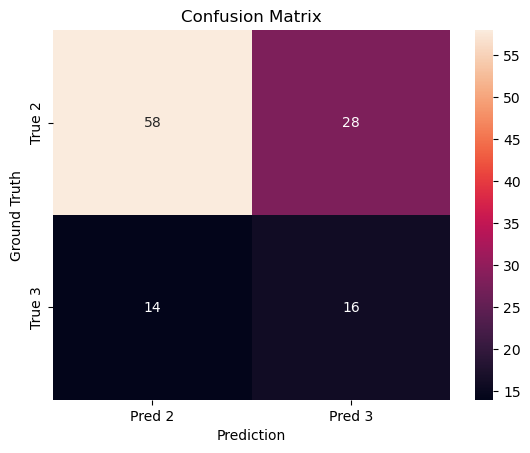

In [14]:
cm = confusion_matrix(all_true, all_pred, labels=[2, 3])

sns.heatmap(
    cm, annot=True, fmt="d",
    xticklabels=["Pred 2", "Pred 3"],
    yticklabels=["True 2", "True 3"]
)
plt.xlabel("Prediction")
plt.ylabel("Ground Truth")
plt.title("Confusion Matrix")
plt.show()


## **Recall for class-3**

In [15]:
recall_3 = recall_score(all_true, all_pred, pos_label=3)
print("Recall (Class 3):", recall_3)


Recall (Class 3): 0.5333333333333333


In [16]:
macro_f1 = f1_score(all_true, all_pred, average="macro")
print("Macro F1:", macro_f1)


Macro F1: 0.5833048238111529


## **Accuracy**

In [17]:
acc = accuracy_score(all_true, all_pred)
print("Accuracy:", acc)


Accuracy: 0.6379310344827587


# **Trying second method**

In [5]:
import os
import numpy as np
import pandas as pd
import nibabel as nib
import cv2
from glob import glob

import torch
import torch.nn as nn
import torchvision.models as models

from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    confusion_matrix,
    recall_score,
    f1_score,
    accuracy_score,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns


In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [6]:
df_path = r"D:\Similiar_Colorectum\14004841\case_labels.csv"
df = pd.read_csv(df_path)

print(df.head())
print("\nLabel distribution:")
print(df['label'].value_counts())


  case_id  label
0  CRC002      3
1  CRC004      3
2  CRC005      3
3  CRC006      2
4  CRC014      2

Label distribution:
label
2    86
3    30
Name: count, dtype: int64


In [7]:
IMG_DIR  = r"D:\Similiar_Colorectum\14004841\images\images"
MASK_DIR = r"D:\Similiar_Colorectum\14004841\lms\lms"


In [8]:
def get_tumor_slices(ct_path, mask_path):
    ct = nib.load(ct_path).get_fdata()
    mask = nib.load(mask_path).get_fdata()

    tumor_slices = []

    for z in range(ct.shape[2]):
        if np.any((mask[:, :, z] == 2) | (mask[:, :, z] == 3)):
            tumor_slices.append(ct[:, :, z])

    return tumor_slices


In [9]:
def preprocess_slice(slice2d, size=224):
    slice2d = np.nan_to_num(slice2d)

    # CT window
    wl, ww = 40, 400
    low, high = wl - ww//2, wl + ww//2
    slice2d = np.clip(slice2d, low, high)

    # Normalize
    slice2d = (slice2d - slice2d.min()) / (slice2d.max() - slice2d.min() + 1e-6)

    slice2d = cv2.resize(slice2d, (size, size))
    slice2d = np.stack([slice2d]*3, axis=0)

    return torch.tensor(slice2d, dtype=torch.float32)


In [12]:
resnet = models.resnet18(pretrained=True)
resnet.fc = nn.Identity()
resnet = resnet.to(device)
resnet.eval()


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [13]:
def extract_case_features(ct_path, mask_path):
    slices = get_tumor_slices(ct_path, mask_path)
    features = []

    with torch.no_grad():
        for s in slices:
            img = preprocess_slice(s).unsqueeze(0).to(device)
            feat = resnet(img)
            features.append(feat.cpu().numpy())

    return np.vstack(features)   # (num_slices, 512)


In [14]:
def mil_topk_pool(features, k=5):
    norms = np.linalg.norm(features, axis=1)
    topk_idx = np.argsort(norms)[-k:]
    return features[topk_idx].mean(axis=0)


In [15]:
def compute_tumor_volume(mask_path):
    mask = nib.load(mask_path).get_fdata()
    return np.sum((mask == 2) | (mask == 3))


In [16]:
X, y = [], []

for case_id, label in zip(df.case_id, df.label):

    ct_candidates = glob(f"{IMG_DIR}/crc_{case_id}_*.nii.gz")
    mask_candidates = glob(f"{MASK_DIR}/crc_{case_id}_*.nii.gz")

    if len(ct_candidates) == 0 or len(mask_candidates) == 0:
        continue

    ct_path = ct_candidates[0]
    mask_path = mask_candidates[0]

    feats = extract_case_features(ct_path, mask_path)
    case_feat = mil_topk_pool(feats, k=5)

    volume = compute_tumor_volume(mask_path)
    case_feat = np.concatenate([case_feat, [volume]])

    X.append(case_feat)
    y.append(label)

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)   # (~116, 513)
print("y shape:", y.shape)


X shape: (116, 513)
y shape: (116,)


In [17]:
import pandas as pd
import numpy as np

# Create feature column names
feature_cols = [f"feat_{i}" for i in range(X.shape[1])]

X_df = pd.DataFrame(X, columns=feature_cols)
y_df = pd.DataFrame({"label": y})

# Combine
data_df = pd.concat([X_df, y_df], axis=1)

csv_path = r"D:\Similiar_Colorectum\14004841\mil_features_Xy.csv"
data_df.to_csv(csv_path, index=False)

print("Saved X and y to:", csv_path)


Saved X and y to: D:\Similiar_Colorectum\14004841\mil_features_Xy.csv


In [18]:
print(X)

[[9.39287663e-01 3.71367157e-01 1.86567569e+00 ... 3.38858753e-01
  4.99985933e-01 3.39000000e+03]
 [3.74261498e-01 4.90600914e-01 1.33506513e+00 ... 1.69153839e-01
  5.45260429e-01 1.25060000e+04]
 [1.27441072e+00 2.53040135e-01 1.73773670e+00 ... 3.05025071e-01
  3.22757542e-01 7.09480000e+04]
 ...
 [1.47423863e+00 9.58189964e-01 8.20415139e-01 ... 2.33505517e-01
  4.98339832e-01 2.23000000e+02]
 [1.73430181e+00 5.85179508e-01 1.08773756e+00 ... 2.21461952e-02
  7.75087059e-01 1.84800000e+03]
 [9.86158550e-01 5.76041996e-01 2.11987543e+00 ... 6.38853535e-02
  9.59867090e-02 3.60500000e+03]]


In [12]:
# clf = LogisticRegression(
#     class_weight="balanced",
#     max_iter=1000
# )


In [13]:
from sklearn.svm import SVC

clf = SVC(
    kernel="linear",
    class_weight="balanced",
    probability=True
)


In [14]:
import time

start_time = time.time()

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

all_true, all_pred = [], []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    fold_start = time.time()

    clf.fit(X[train_idx], y[train_idx])
    preds = clf.predict(X[val_idx])

    all_true.extend(y[val_idx])
    all_pred.extend(preds)

    print(f"Fold {fold} done in {time.time() - fold_start:.2f} sec")

print(f"\nTotal time: {time.time() - start_time:.2f} sec")


Fold 1 done in 340.53 sec
Fold 2 done in 649.30 sec
Fold 3 done in 285.18 sec
Fold 4 done in 191.08 sec
Fold 5 done in 300.00 sec

Total time: 1766.15 sec


In [15]:
# skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# all_true, all_pred = [], []

# for train_idx, val_idx in skf.split(X, y):
#     clf.fit(X[train_idx], y[train_idx])
#     preds = clf.predict(X[val_idx])

#     all_true.extend(y[val_idx])
#     all_pred.extend(preds)


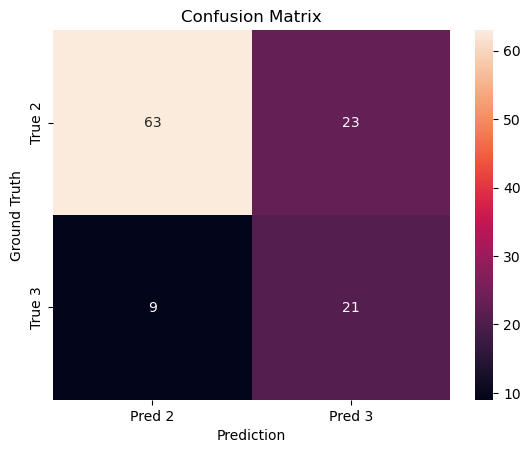

In [16]:
cm = confusion_matrix(all_true, all_pred, labels=[2, 3])

sns.heatmap(
    cm, annot=True, fmt="d",
    xticklabels=["Pred 2", "Pred 3"],
    yticklabels=["True 2", "True 3"]
)
plt.xlabel("Prediction")
plt.ylabel("Ground Truth")
plt.title("Confusion Matrix")
plt.show()


In [17]:
recall_3 = recall_score(all_true, all_pred, pos_label=3)
macro_f1 = f1_score(all_true, all_pred, average="macro")
acc = accuracy_score(all_true, all_pred)

print("Accuracy:", acc)
print("Recall (Class 3):", recall_3)
print("Macro F1:", macro_f1)

print("\nDetailed report:")
print(classification_report(all_true, all_pred, labels=[2,3]))


Accuracy: 0.7241379310344828
Recall (Class 3): 0.7
Macro F1: 0.6825179609989737

Detailed report:
              precision    recall  f1-score   support

           2       0.88      0.73      0.80        86
           3       0.48      0.70      0.57        30

    accuracy                           0.72       116
   macro avg       0.68      0.72      0.68       116
weighted avg       0.77      0.72      0.74       116



# **All Model Comparision**

In [1]:
# Core
import numpy as np
import pandas as pd

# Model selection & evaluation
from sklearn.model_selection import StratifiedKFold

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

# Visualization (for confusion matrix etc.)
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        max_iter=1000
    ),

    "Linear SVM": SVC(
        kernel="linear",
        class_weight="balanced",
        probability=True
    ),

    "RBF SVM": SVC(
        kernel="rbf",
        class_weight="balanced",
        probability=True
    ),

    "Naive Bayes": GaussianNB(),

    "LDA": LinearDiscriminantAnalysis(),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "kNN": KNeighborsClassifier(
        n_neighbors=7
    )
}


In [3]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)
from sklearn.model_selection import StratifiedKFold


def evaluate_model(name, model, X, y):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    y_true_all, y_pred_all = [], []

    for train_idx, val_idx in skf.split(X, y):
        model.fit(X[train_idx], y[train_idx])
        preds = model.predict(X[val_idx])

        y_true_all.extend(y[val_idx])
        y_pred_all.extend(preds)

    # --- Base metrics ---
    acc = accuracy_score(y_true_all, y_pred_all)

    # Classification report as dict (VERY IMPORTANT)
    report = classification_report(
        y_true_all,
        y_pred_all,
        labels=[2, 3],
        output_dict=True
    )

    return {
        "Model": name,

        # Overall
        "Accuracy": acc,

        # ----- Class 2 -----
        "Precision_Class2": report["2"]["precision"],
        "Recall_Class2": report["2"]["recall"],
        "F1_Class2": report["2"]["f1-score"],

        # ----- Class 3 -----
        "Precision_Class3": report["3"]["precision"],
        "Recall_Class3": report["3"]["recall"],
        "F1_Class3": report["3"]["f1-score"],

        # ----- Macro -----
        "Macro_Precision": report["macro avg"]["precision"],
        "Macro_Recall": report["macro avg"]["recall"],
        "Macro_F1": report["macro avg"]["f1-score"],

        # ----- Weighted -----
        "Weighted_Precision": report["weighted avg"]["precision"],
        "Weighted_Recall": report["weighted avg"]["recall"],
        "Weighted_F1": report["weighted avg"]["f1-score"],

        # Keep predictions for confusion matrix
        "y_true": y_true_all,
        "y_pred": y_pred_all
    }


In [4]:


data_df = pd.read_csv(r"D:\Similiar_Colorectum\14004841\mil_features_Xy.csv")

X = data_df.drop(columns=["label"]).values
y = data_df["label"].values

print(X.shape, y.shape)


(116, 513) (116,)


In [5]:
results = []

for name, model in models.items():
    print(f"Evaluating {name}")
    res = evaluate_model(name, model, X, y)
    results.append(res)


Evaluating Logistic Regression


c:\Users\100ra\anaconda3\envs\ram_env\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\100ra\anaconda3\envs\ram_env\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#log

Evaluating Linear SVM
Evaluating RBF SVM
Evaluating Naive Bayes
Evaluating LDA
Evaluating Random Forest
Evaluating Gradient Boosting
Evaluating kNN


c:\Users\100ra\anaconda3\envs\ram_env\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\100ra\anaconda3\envs\ram_env\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\100ra\anaconda3\envs\ram_env\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\100ra\anaconda3\envs\ram_env\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\100ra\anaconda3\envs\ram_env\Lib\subprocess.py", line

In [6]:
results_df = pd.DataFrame(results)[[
    "Model",
    "Accuracy",

    "Precision_Class2", "Recall_Class2", "F1_Class2",
    "Precision_Class3", "Recall_Class3", "F1_Class3",

    "Macro_Precision", "Macro_Recall", "Macro_F1",
    "Weighted_Precision", "Weighted_Recall", "Weighted_F1"
]]

# Sort by clinical priority
results_df = results_df.sort_values(
    by="Recall_Class3", ascending=False
)

results_df


,Model,Accuracy,Precision_Class2,Recall_Class2,F1_Class2,Precision_Class3,Recall_Class3,F1_Class3,Macro_Precision,Macro_Recall,Macro_F1,Weighted_Precision,Weighted_Recall,Weighted_F1
1,Linear SVM,0.724138,0.875000,0.732558,0.797468,0.477273,0.700000,0.567568,0.676136,0.716279,0.682518,0.772139,0.724138,0.738011
0,Logistic Regression,0.750000,0.835294,0.825581,0.830409,0.516129,0.533333,0.524590,0.675712,0.679457,0.677500,0.752751,0.750000,0.751318
3,Naive Bayes,0.784483,0.821053,0.906977,0.861878,0.619048,0.433333,0.509804,0.720050,0.670155,0.685841,0.768810,0.784483,0.770825
2,RBF SVM,0.810345,0.820000,0.953488,0.881720,0.750000,0.400000,0.521739,0.785000,0.676744,0.701730,0.801897,0.810345,0.788622
7,kNN,0.793103,0.816327,0.930233,0.869565,0.666667,0.400000,0.500000,0.741497,0.665116,0.684783,0.777621,0.793103,0.773988
6,Gradient Boosting,0.750000,0.806452,0.872093,0.837989,0.521739,0.400000,0.452830,0.664095,0.636047,0.645410,0.732819,0.750000,0.738379
4,LDA,0.689655,0.784091,0.802326,0.793103,0.392857,0.366667,0.379310,0.588474,0.584496,0.586207,0.682910,0.689655,0.686088
5,Random Forest,0.758621,0.754386,1.000000,0.860000,1.000000,0.066667,0.125000,0.877193,0.533333,0.492500,0.817907,0.758621,0.669914


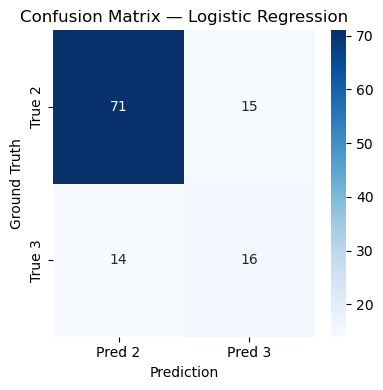

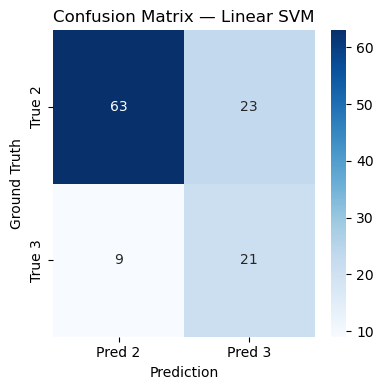

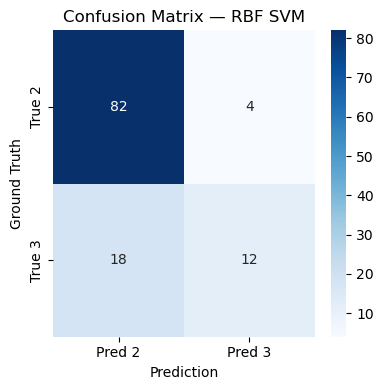

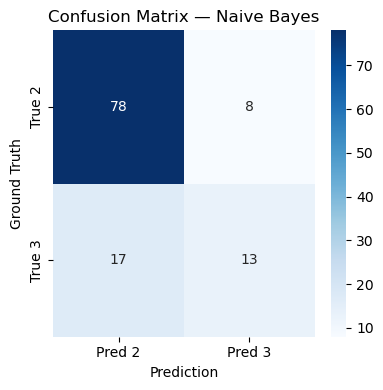

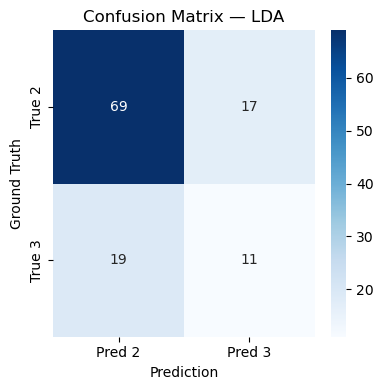

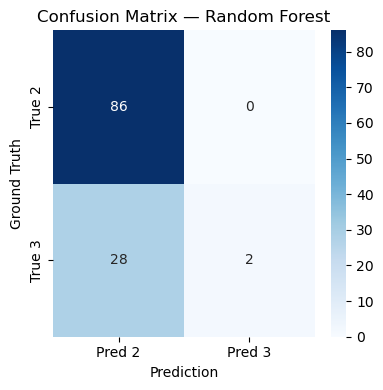

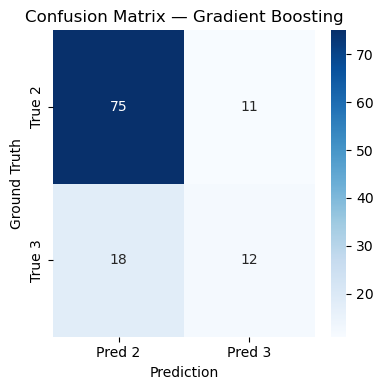

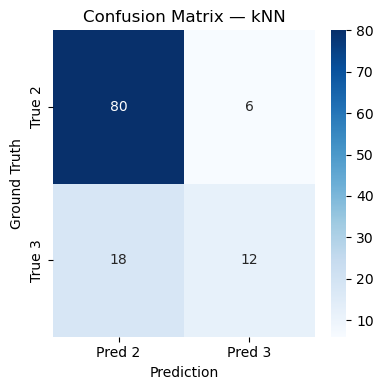

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

for res in results:
    cm = confusion_matrix(
        res["y_true"],
        res["y_pred"],
        labels=[2, 3]
    )

    plt.figure(figsize=(4, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Pred 2", "Pred 3"],
        yticklabels=["True 2", "True 3"]
    )
    plt.title(f"Confusion Matrix — {res['Model']}")
    plt.xlabel("Prediction")
    plt.ylabel("Ground Truth")
    plt.tight_layout()
    plt.show()


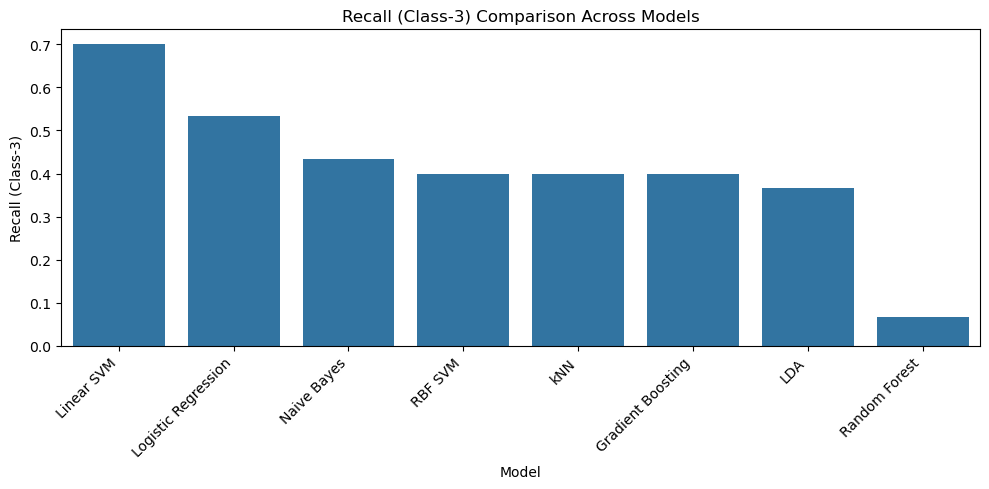

In [8]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=results_df,
    x="Model",
    y="Recall_Class3"
)
plt.xticks(rotation=45, ha="right")
plt.title("Recall (Class-3) Comparison Across Models")
plt.ylabel("Recall (Class-3)")
plt.tight_layout()
plt.show()
